# CivilComments quickstart

Toxicity detection from Shanmugam et al., NeurIPS 2025. Seven released classifiers are estimated from 20 visible labels and 1,000 unlabeled comments. The remaining comments are held out and are not used to fit SSME.

The interactive report for this split is [results/report/report.html](results/report/report.html). The two figures below use the 5-seed benchmark from `ssme-lite configs/civilcomments.json`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ssme_lite import SSMEEstimator, SemiSupervisedSplit
from ssme_lite.benchmark import official_scores

def package_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents, here / 'ssme-lite']:
        if (candidate / 'ssme_lite' / '__init__.py').is_file():
            return candidate
    raise FileNotFoundError('Open this notebook from the ssme-lite repository.')

ROOT = package_root()
DATA = ROOT.parent / 'official' / 'SSME' / 'inputs'
BENCHMARK = ROOT.parent / 'results' / 'civilcomments'
OUT = ROOT / 'experiments' / 'civilcomments' / 'results'
scores, y, names = official_scores(DATA, 'CivilComments')
print(f'{scores.shape[0]} comments, {scores.shape[1]} models, {int(y.sum())} toxic labels')

133782 comments, 7 models, 15224 toxic labels


## One split, one report

`random_state=0` matches the first seed of the benchmark. The page intervals are latent-label uncertainty given this fit, not standard errors across seeds.

In [2]:
splitter = SemiSupervisedSplit(n_labeled=20, n_unlabeled=1000, random_state=0)
parts = splitter.indices(len(y))
if splitter.labeled_class_count(y, parts) != scores.shape[-1]:
    raise RuntimeError('labeled draw missed a class')
estimator = SSMEEstimator(max_iter=100, early_stopping=False, random_state=0)
estimator.fit(scores[parts['estimation']], splitter.partial_labels(y, parts), model_names=names)
report = estimator.report(
    n_draws=100,
    title='CivilComments',
    primary_metric='accuracy',
    sample_ids=parts['estimation'],
)
report.save(OUT / 'report')
ranking = report.ranking('accuracy')
print(ranking.to_string(index=False))
print(OUT / 'report' / 'report.html')

        model   metric  estimate  label_std  mc_standard_error  interval_low  interval_high  valid_draws  rank
alg_IRM_seed1 accuracy  0.949081   0.005904                0.0      0.937206       0.959804          100   1.0
      alg_IRM accuracy  0.941219   0.005118                0.0      0.930858       0.950980          100   2.0
alg_ERM_seed2 accuracy  0.934280   0.005759                0.0      0.923480       0.944118          100   3.0
      alg_ERM accuracy  0.929831   0.005379                0.0      0.919608       0.940245          100   4.0
alg_ERM_seed1 accuracy  0.926612   0.006060                0.0      0.914706       0.937304          100   5.0
alg_IRM_seed2 accuracy  0.922760   0.005232                0.0      0.914706       0.932353          100   6.0
    alg_CORAL accuracy  0.827901   0.005626                0.0      0.818113       0.839828          100   7.0
/Users/jason/Desktop/研一上/机器学习与 Python 应用/ssme-lite/experiments/civilcomments/results/report/report.html


## How the estimates compare with holdout labels

The left figure is relative mean absolute error. RMAE divides SSME's held-out error by the labeled-only error, so the dashed line at 1 is the labeled-only baseline. A point to the left of that line is a smaller error.

The right figure is the same comparison for each model, in percentage points, for AUC and Accuracy. Both panels use the mean over the five benchmark seeds.

RMAE {'ACC': np.float64(0.664), 'ECE': np.float64(0.719), 'AUC': np.float64(1.036), 'AUPRC': np.float64(0.707)}


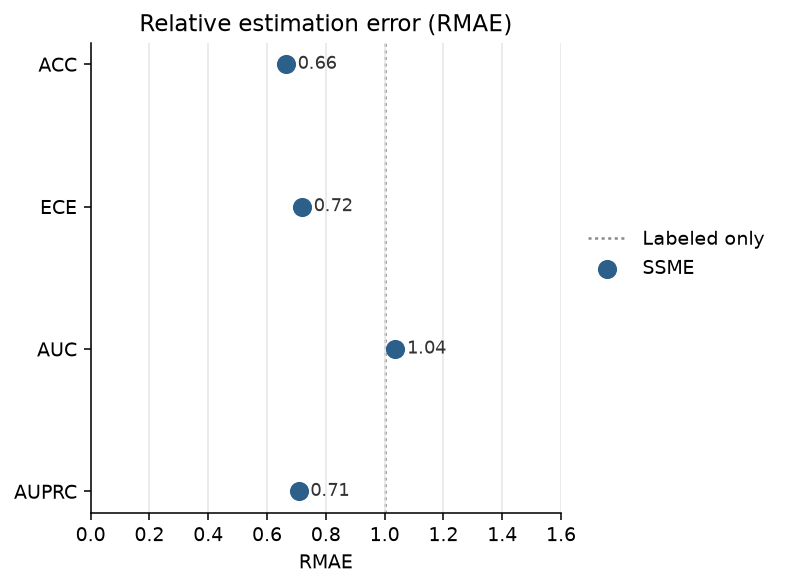

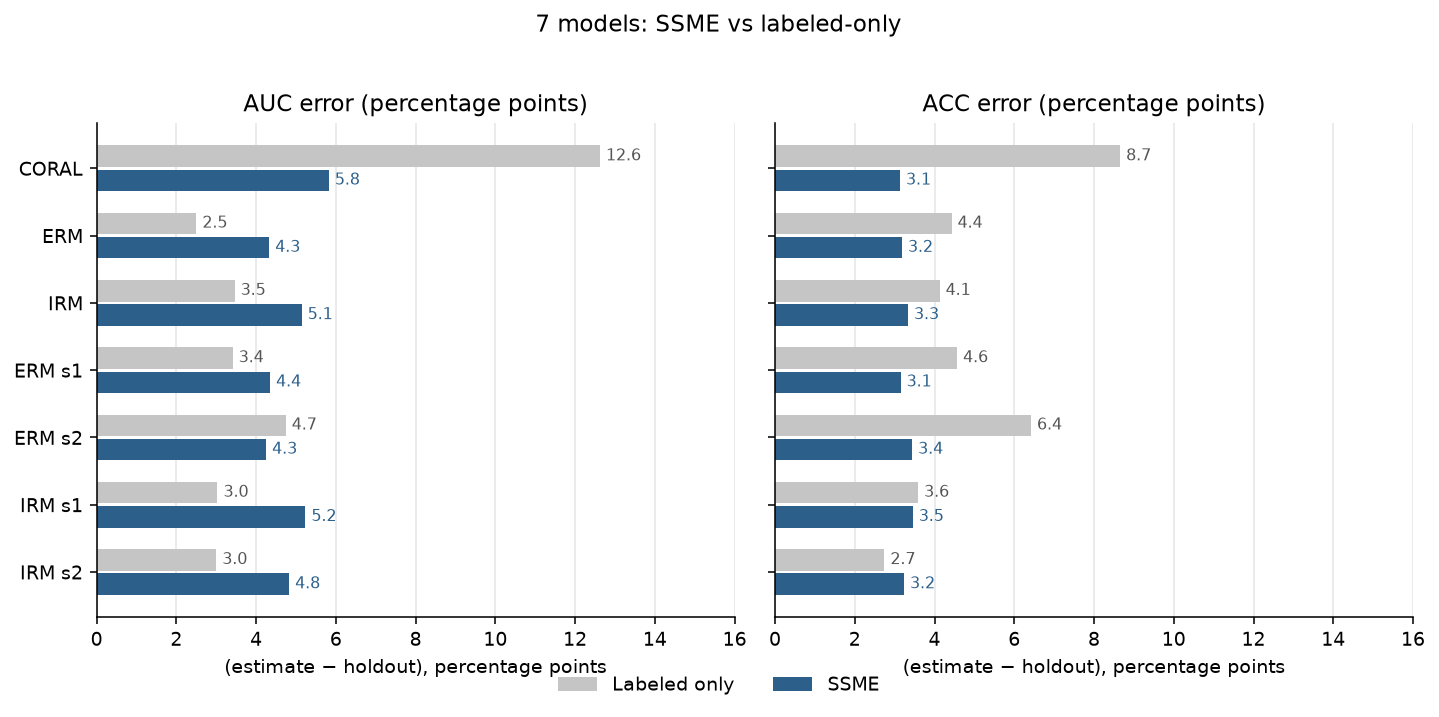

In [3]:
summary = pd.read_csv(BENCHMARK / 'summary.csv')
details = pd.read_csv(BENCHMARK / 'details.csv')
held = summary[summary.target == 'heldout'].set_index(['metric', 'method'])
metric_order = ['accuracy', 'ece', 'auc', 'auprc']
metric_labels = ['ACC', 'ECE', 'AUC', 'AUPRC']
rmae = np.array([held.loc[(m, 'ssme'), 'mae'] / held.loc[(m, 'labeled_only'), 'mae'] for m in metric_order])

labeled_color, ssme_color = '#c5c5c5', '#2c5f8a'
fig, ax = plt.subplots(figsize=(5.8, 4.3))
y_pos = np.arange(len(metric_order))[::-1]
ax.axvline(1, color='#8a8a8a', linestyle=(0, (1.2, 1.4)), linewidth=1.3, label='Labeled only', zorder=1)
ax.scatter(rmae, y_pos, s=78, color=ssme_color, zorder=3, label='SSME')
for value, y in zip(rmae, y_pos):
    ax.text(value + 0.04, y, f'{value:.2f}', va='center', fontsize=9, color='#333333')
ax.set_yticks(y_pos, metric_labels)
ax.set_xlim(0, 1.6)
ax.set_xlabel('RMAE')
ax.set_title('Relative estimation error (RMAE)')
ax.grid(axis='x', color='#e6e6e6', zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.55))
fig.tight_layout()
fig.savefig(OUT / 'rmae.png', dpi=160, bbox_inches='tight')
plt.show()

model_order = [
    ('alg_CORAL', 'CORAL'),
    ('alg_ERM', 'ERM'),
    ('alg_IRM', 'IRM'),
    ('alg_ERM_seed1', 'ERM s1'),
    ('alg_ERM_seed2', 'ERM s2'),
    ('alg_IRM_seed1', 'IRM s1'),
    ('alg_IRM_seed2', 'IRM s2'),
]
per_model = (details[details.target == 'heldout']
             .groupby(['model', 'metric', 'method'], as_index=False)['absolute_error'].mean())
per_model['pp'] = per_model.absolute_error * 100

def panel(metric):
    rows = per_model[per_model.metric == metric].set_index(['model', 'method'])
    labeled = [rows.loc[(name, 'labeled_only'), 'pp'] for name, _ in model_order]
    ssme = [rows.loc[(name, 'ssme'), 'pp'] for name, _ in model_order]
    return np.array(labeled), np.array(ssme)

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.8), sharey=True)
positions = np.arange(len(model_order))
for ax, metric, title in zip(axes, ['auc', 'accuracy'], ['AUC error (percentage points)', 'ACC error (percentage points)']):
    labeled, ssme = panel(metric)
    ax.barh(positions - 0.18, labeled, height=0.32, color=labeled_color, label='Labeled only', zorder=2)
    ax.barh(positions + 0.18, ssme, height=0.32, color=ssme_color, label='SSME', zorder=2)
    for y, value in zip(positions - 0.18, labeled):
        ax.text(value + 0.15, y, f'{value:.1f}', va='center', fontsize=8, color='#555555')
    for y, value in zip(positions + 0.18, ssme):
        ax.text(value + 0.15, y, f'{value:.1f}', va='center', fontsize=8, color=ssme_color)
    ax.set_yticks(positions, [label for _, label in model_order])
    ax.set_xlim(0, 16)
    ax.set_xlabel('(estimate − holdout), percentage points')
    ax.set_title(title)
    ax.grid(axis='x', color='#e6e6e6', zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].invert_yaxis()
axes[0].set_ylabel('')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('7 models: SSME vs labeled-only', y=1.02)
fig.tight_layout()
fig.savefig(OUT / 'model_errors.png', dpi=160, bbox_inches='tight')
plt.show()
print('RMAE', dict(zip(metric_labels, np.round(rmae, 3))))